# Modelo final

In [18]:
# El siguiente codigo sirve para que el notebook funcione igual en colab o en local
# Si se ejecuta en la nube se cargue el repositorio, de esta forma se pueda acceder 
# a los diferentes archivos que necesite para su ejecución de forma automatica
import sys
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_path = '/content/eye_diseases_classification_trabajo_DL'
    if not os.path.exists(repo_path):
        !git clone https://github.com/ropas5/eye_diseases_classification_trabajo_DL.git
        sys.path.append('/content/eye_diseases_classification_trabajo_DL/notebooks')
    # from google.colab import userdata
    # userdata.get('kaggle')
    else:
        print("Repo ya existe, actualizando")
        %cd /content/eye_diseases_classification_trabajo_DL/notebooks
        !git pull 
        
    #Cargamos el kaggle.json
    import ipywidgets as widgets
    from IPython.display import display
    
    uploader = widgets.FileUpload(accept='.json')
    display(uploader)
else:
    print("Ejecución en local")
    uploader = None

Ejecución en local


Con la tabla con los resultados vamos ha hacer un grafico comparando los modelos imples y los complejos y entonces decicir cual es el mejor modelo complejidad rendimiento. Para compararlos hemos escogido la métrica F1 en Test.

In [48]:
import pandas as pd

df = pd.read_csv("data/processed/model_results.csv")

df

,modelo,epochs,Train Accuracy,Val Accuracy,Test Accuracy,Train F1,Val F1,Test F1
0,modelo_3,140,0.469751,0.483412,0.462085,0.467340,0.480129,0.462396
1,modelo_2_simple,200,0.811388,0.806872,0.795024,0.801620,0.792162,0.784455
2,modelo_3_simple,160,0.762357,0.748815,0.718009,0.744839,0.734888,0.698080
3,modelo_4_simple,160,0.879794,0.866114,0.859005,0.877048,0.859835,0.854445
4,modelo_5_simple,160,0.741795,0.736967,0.718009,0.725975,0.723727,0.703048
5,modelo_6_simple,100,0.811000,0.815000,0.808000,0.793000,0.798000,0.789000
6,modelo_vgg,70,0.866000,0.850000,0.853000,0.865000,0.847000,0.850000
7,modelo_vgg_2,40,0.972716,0.924739,0.915782,0.968023,0.913524,0.927242
8,modelo_vgg_3,40,0.999209,0.906980,0.913507,0.999209,0.906495,0.913191
9,modelo_vgg_4,40,0.997628,0.914692,0.926540,0.997628,0.914033,0.925701


In [ ]:
df_simple= df[:5][["modelo", "Test F1"]]
df_complejo = df[6:][["modelo", "Test F1"]]

,modelo,Test F1
0,modelo_3,0.462396
1,modelo_2_simple,0.784455
2,modelo_3_simple,0.698080
3,modelo_4_simple,0.854445
4,modelo_5_simple,0.703048


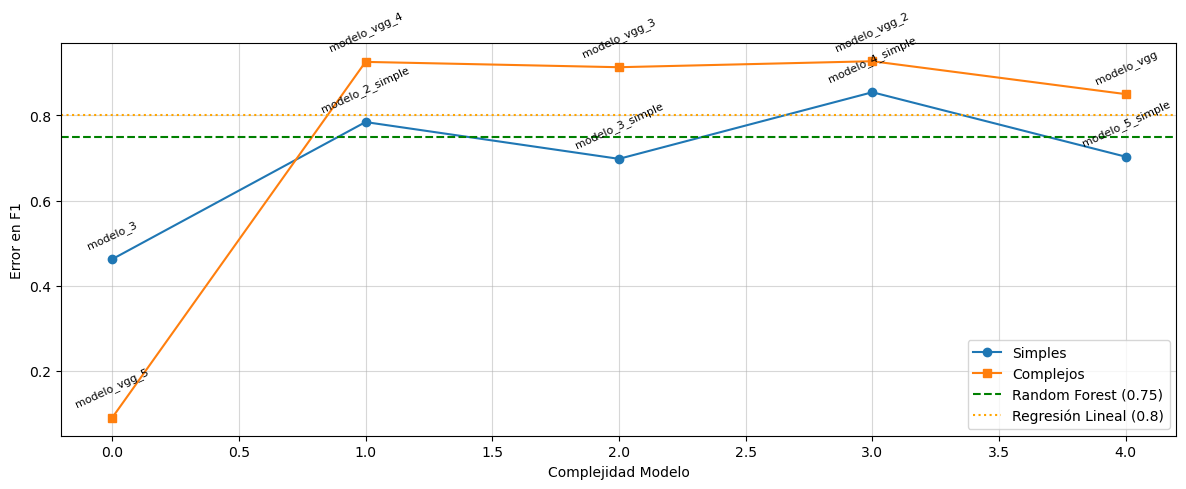

In [58]:
import matplotlib.pyplot as plt
# Invertir el orden de los complejos para representar de menos a mas complejidad
df_complejo_inv = df_complejo.iloc[::-1].reset_index(drop=True)

# Valores de el modelo lineal y el Random forest
rf_f1    = 0.75   # Rando forest Test F1
ms_f1    = 0.8  # Modelo Simple Test F1 

plt.figure(figsize=(12, 5))

plt.plot(df_simple.index, df_simple["Test F1"],
         marker="o", label="Simples")
plt.plot(df_complejo_inv.index, df_complejo_inv["Test F1"],
         marker="s", label="Complejos")

# Anotar nombres de modelos simples
for i, row in df_simple.iterrows():
    plt.annotate(row["modelo"], xy=(i, row["Test F1"]),
                 xytext=(0, 8), textcoords="offset points",
                 ha="center", fontsize=8, rotation=25)

# Anotar nombres de modelos complejos
for i, row in df_complejo_inv.iterrows():
    plt.annotate(row["modelo"], xy=(i, row["Test F1"]),
                 xytext=(0, 8), textcoords="offset points",
                 ha="center", fontsize=8, rotation=25)
    
# Líneas de referencia
plt.axhline(rf_f1, color="green",  linestyle="--", linewidth=1.5, label=f"Random Forest ({rf_f1})")
plt.axhline(ms_f1, color="orange", linestyle=":",  linewidth=1.5, label=f"Regresión Lineal ({ms_f1})")

plt.ylabel("Error en F1")
plt.xlabel("Complejidad Modelo")
plt.grid(alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Podemos ver en el gráfico que el modelo que mejor marca tiene y menos complejo es el modelo 4. Que esta más cerca de los modelos complejos con mejor rendimiento, por un coste de parametros mucho menor. Siendo que el modelo 4 tiene 5428 parametros, en comparación los modelos complejos 3 y 4 tiene respectibamente 8030276 y 1999428. 

Importamos el modelo 4 y lo rejecutamos para poder ver mejor más en detalle sus caracteristicas.

In [19]:
from notebooks.importacion_preprocesado import descarga_y_carga_de_datos, preprocesamiento


tamany_img = (128,128) # tamaño reducido para colab, porque si no supera la ram
X, y = descarga_y_carga_de_datos(target_size=tamany_img, uploader=uploader)

X_train, X_val, X_test, y_train, y_val, y_test = preprocesamiento(X, y)

Dataset no encontrado, descargando y extrayendo...
Ejecutando en local
Dataset extraído en: ../data/raw\dataset
X shape: (4217, 128, 128, 3) y shape: (4217,)


In [20]:
# Importar el modelo
import sys
sys.path.append('../')

import importlib
import models.simple_4_cnn
importlib.reload(models.simple_4_cnn) # recargamos el cache para tener la ultima versión del modelo 
from models.simple_4_cnn import create_model

# Crear el modelo
model = create_model(input_shape=(128,128,3), num_classes=4, l_rate=0.01)

c:\Users\roger\miniconda3\envs\dl\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 122, 122, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,428 (21.20 KB)

 Trainable params: 5,428 (21.20 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=160
)

Epoch 1/160
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 153ms/step - accuracy: 0.3310 - loss: 1.3246 - val_accuracy: 0.4396 - val_loss: 1.2136
Epoch 2/160
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.4508 - loss: 1.1956 - val_accuracy: 0.4479 - val_loss: 1.1847
Epoch 3/160
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.4496 - loss: 1.1442 - val_accuracy: 0.4727 - val_loss: 1.1069
Epoch 4/160
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - accuracy: 0.4571 - loss: 1.1256 - val_accuracy: 0.4502 - val_loss: 1.1302
Epoch 5/160
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - accuracy: 0.4717 - loss: 1.0885 - val_accuracy: 0.4905 - val_loss: 1.0674
Epoch 6/160
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.4781 - loss: 1.0749 - val_accuracy: 0.4846 - val_loss: 1.0693
Epoch 7/160
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.4966 - loss: 1.0586 - val_accuracy: 0.4893 - val_loss: 1.0627
Epoch 8/160
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - accuracy: 0.4899 - loss: 1.0781 - 

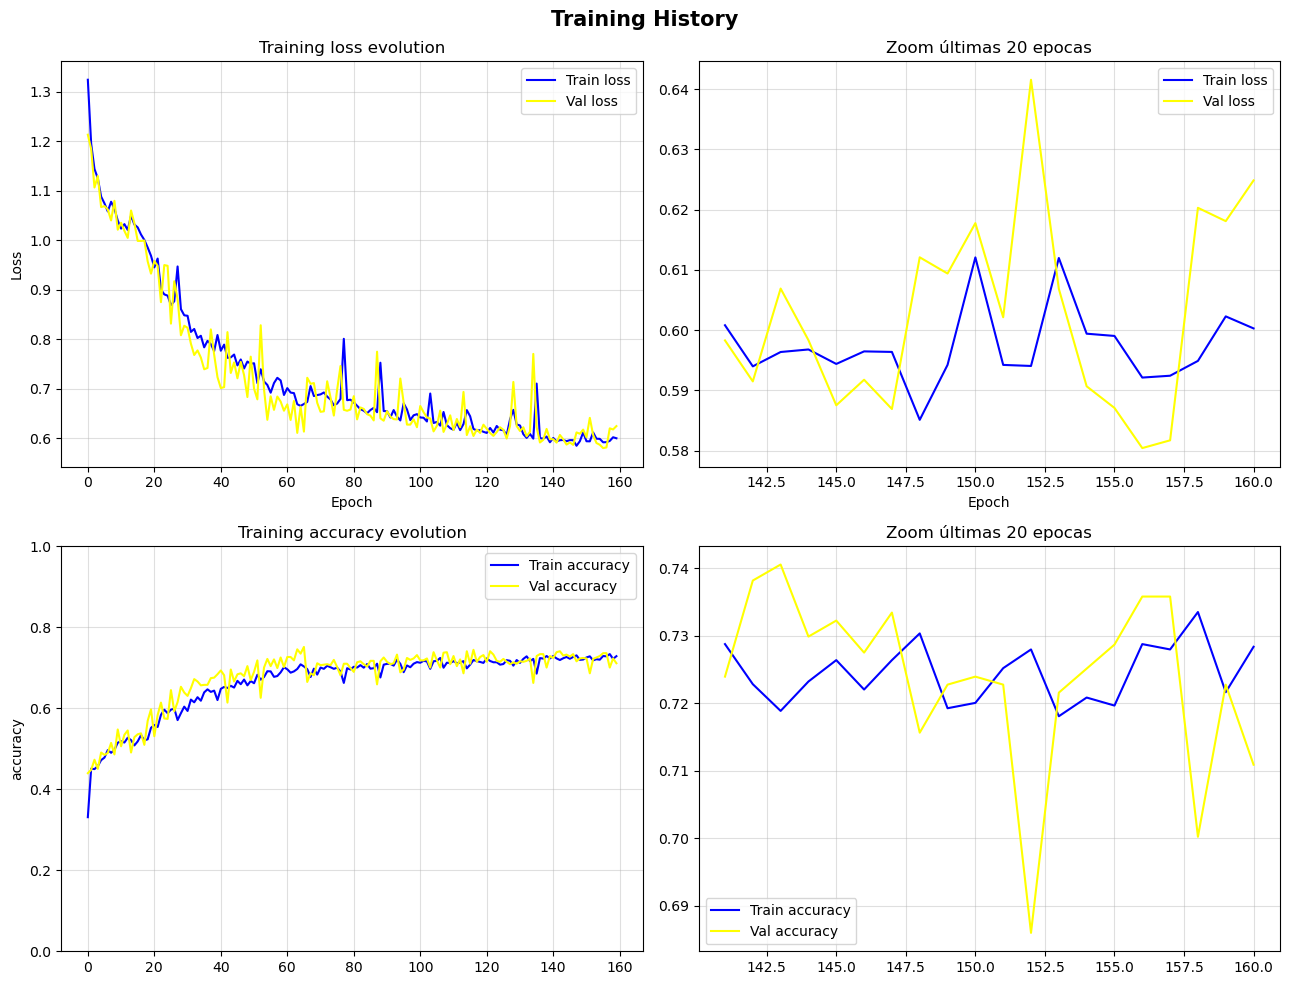

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# número de épocas para el zoom
zoom_epochs = 20

loss = hist.history['loss']
val_loss = hist.history['val_loss']
acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]

epochs = range(1, len(loss) + 1)

fig, ax = plt.subplots(2, 2, figsize=(13,10))
ax  = ax.flatten()
fig.suptitle('Training History', fontsize=15, fontweight='bold')

# Visualizacion evolucion loss durante el entrenamiento
ax[0].plot( loss, label='Train loss', color = "blue")
ax[0].plot( val_loss, label='Val loss', color= "yellow")
ax[0].set_title('Training loss evolution')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].grid(True, alpha = 0.4)
ax[0].legend()

# Zoom últimas épocas
ax[1].plot(epochs[-zoom_epochs:], loss[-zoom_epochs:], label='Train loss', color = "blue")
ax[1].plot(epochs[-zoom_epochs:], val_loss[-zoom_epochs:], label='Val loss', color= "yellow")
ax[1].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[1].set_xlabel('Epoch')
ax[1].grid(True, alpha = 0.4)
ax[1].legend()

# Visualizacion de accuracy durante el entrenamiento
ax[2].plot( acc, label='Train accuracy', color = "blue")
ax[2].plot( val_acc, label='Val accuracy', color= "yellow")
ax[2].grid(True, alpha = 0.4)
ax[2].set_ylim(0,1)
ax[2].set_title('Training accuracy evolution')
ax[2].set_ylabel('accuracy')
ax[2].legend()

# Zoom últimas épocas
ax[3].plot(epochs[-zoom_epochs:], acc[-zoom_epochs:], label='Train accuracy', color = "blue")
ax[3].plot(epochs[-zoom_epochs:], val_acc[-zoom_epochs:], label='Val accuracy', color= "yellow")
ax[3].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[3].grid(True, alpha = 0.4)
ax[3].legend()

plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

datasets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test)
}

def evaluate(model, X, y):
    #Convertir a enteros
    y_true = np.argmax(y, axis=1)

    y_pred_probs = model.predict(X)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return acc, f1


def crear_df_metricas(model, datasets):
    results = {}
    for split_name, (X, y) in datasets.items():
        acc, f1 = evaluate(model, X, y)
        results[split_name] = [acc, f1]
    
    df = pd.DataFrame(results, index=["Accuracy", "F1"])
    return df

df = crear_df_metricas(model, datasets)


80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


In [25]:
print(df.round(3))

          Train    Val   Test
Accuracy  0.718  0.711  0.701
F1        0.683  0.667  0.662


In [26]:
def plot_barra(metrica, titulo, color):

    plt.figure(figsize=(6,4))
    bars = plt.bar(metrica.index, metrica.values, color=color)
    plt.bar_label(bars)
    plt.title(f"{titulo}: Train vs Validation vs Test")
    plt.ylabel(titulo)
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--')
    plt.show()


def plots_metricas(df):
    #Extraemos la fila
    accuracy = df.loc["Accuracy"]
    f1 = df.loc["F1"]

    #Grafico de Accuracy
    plot_barra(accuracy, titulo = "Accuracy", color="blue")

    #Grafico de 
    plot_barra(f1, titulo ="F1", color = "red")

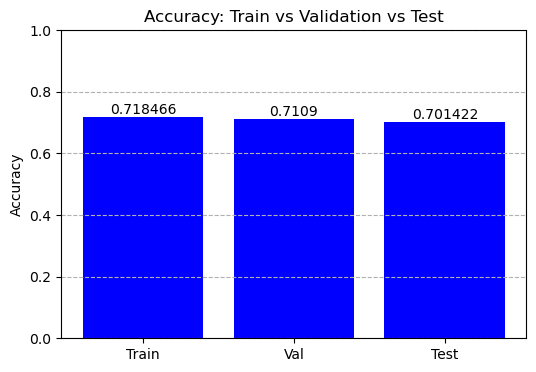

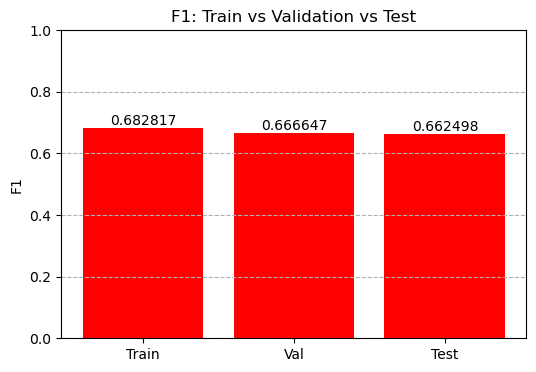

In [27]:
plots_metricas(df)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


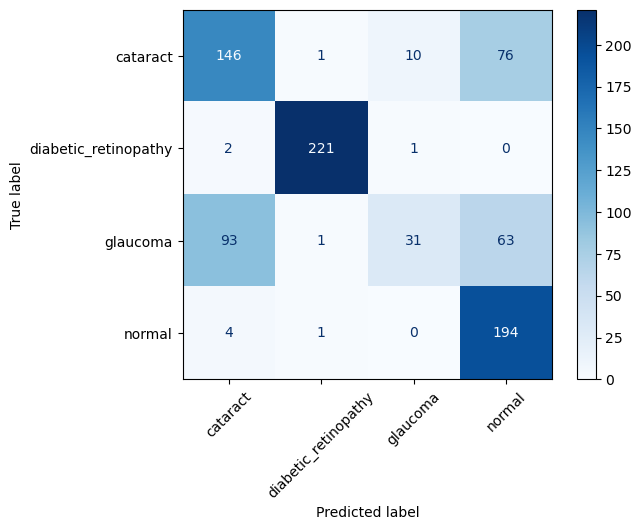

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm,  
                    display_labels= ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
                    ).plot(cmap="Blues", xticks_rotation= 45.0)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


,Train_Accuracy,Train_F1,Val_Accuracy,Val_F1,Test_Accuracy,Test_F1
cataract,0.656,0.614,0.685,0.625,0.627,0.611
diabetic_retinopathy,0.988,0.991,0.970,0.980,0.987,0.987
glaucoma,0.216,0.338,0.138,0.224,0.165,0.270
normal,0.988,0.771,0.977,0.771,0.975,0.729


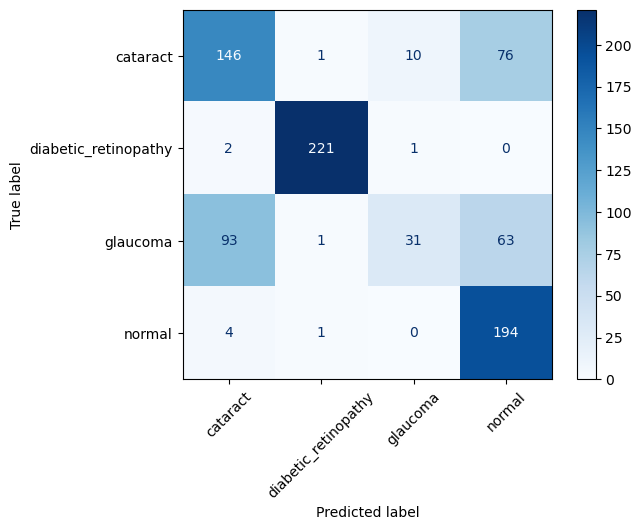

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm,  
                    display_labels= ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
                    ).plot(cmap="Blues", xticks_rotation= 45.0)
from sklearn.metrics import precision_recall_fscore_support

def per_class_table(model, datasets):
    # class_names: lista con nombres de las clases en el orden de los índices (opcional)
    class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]  

    splits = list(datasets.keys())
    # identificamos número de clases desde los datos si no dan nombres
    sample_X, sample_y = next(iter(datasets.values()))
    n_classes = np.argmax(sample_y, axis=1).max() + 1

    # DataFrame con index = clases y columnas por split/metric
    cols = []
    for s in splits:
        cols += [f"{s}_Accuracy", f"{s}_F1"]
    df = pd.DataFrame(index=class_names, columns=cols, dtype=float)

    for split in splits:
        X, y = datasets[split]
        y_true = np.argmax(y, axis=1)
        y_pred = np.argmax(model.predict(X), axis=1)

        # precision, recall, f1 por clase
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=np.arange(n_classes), zero_division=0
        )
        # Aquí definimos "Accuracy" por clase como recall (TP / nº verdaderos de la clase)
        for i, cls in enumerate(class_names):
            df.loc[cls, f"{split}_Accuracy"] = recall[i]
            df.loc[cls, f"{split}_F1"] = f1[i]

    return df

df_per_class = per_class_table(model, datasets)
df_per_class.round(3)